In [1]:
import sys
import os
import uproot

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

# ROOT!
import os, sys
# os.environ["ROOTSYS"] = "/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/software/ROOT/ROOT_6.26.14/install"
# sys.path.append(os.path.join(os.environ["ROOTSYS"], "lib"))

import hipy.hipy.pltext  as pltext
import pandas            as pd
import numpy             as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from WCTE_event_display.EventDisplay      import EventDisplay

from WCSimFilePackages.npz_to_df import simple_truehits_info_to_df, digihits_info_to_df
# from WCSimFilePackages.npz_to_df import super_simple_track_info_to_df

from tqdm import tqdm

plt.style.use('default');
pltext.style()

# Data

In [2]:
events_for_reconstruction = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/run_1766_forBONSAI_separated_chargeFiltered500-12500.csv")

valid_events = pd.read_pickle("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/bonsai/run_1766_validEvents.pkl").values
valid_events = events_for_reconstruction.iloc[valid_events]["event_id"].values
real_events_1766 = events_for_reconstruction[events_for_reconstruction["event_id"].isin(valid_events)]

# real_events_1766 = events_for_reconstruction

pmt_id_1766 = real_events_1766["hit_mpmt_slot_ids"]*19 + real_events_1766["hit_pmt_position_ids"]

real_events_1766["pmt_id"] = pmt_id_1766

/tmp/ipykernel_4113825/3999796321.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_events_1766["pmt_id"] = pmt_id_1766


In [3]:
events_for_reconstruction = pd.read_csv("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/run_1771_forBONSAI_separated_chargeFiltered500-12500.csv")

valid_events = pd.read_pickle("/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/bonsai/run_1771_validEvents_noBONSAICut.pkl").values
valid_events = events_for_reconstruction.iloc[valid_events]["event_id"].values
real_events_1771 = events_for_reconstruction[events_for_reconstruction["event_id"].isin(valid_events)]

# real_events_1771 = events_for_reconstruction

pmt_id_1771 = real_events_1771["hit_mpmt_slot_ids"]*19 + real_events_1771["hit_pmt_position_ids"]

real_events_1771["pmt_id"] = pmt_id_1771

/tmp/ipykernel_4113825/706937758.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_events_1771["pmt_id"] = pmt_id_1771


# Explore Signal And Background Samples

In [4]:
no_candidates_bkg = real_events_1766.event_id.nunique()
no_candidates_sig = real_events_1771.event_id.nunique()

print(no_candidates_bkg, no_candidates_sig)

if no_candidates_bkg < no_candidates_sig:
    event_ids_sig = real_events_1771.event_id.unique()[:no_candidates_bkg]

    real_events_1771 = real_events_1771[
        real_events_1771.event_id.isin(event_ids_sig)
    ]
else:
    event_ids_bkg = real_events_1766.event_id.unique()[:no_candidates_sig]

    real_events_1766 = real_events_1766[
        real_events_1766.event_id.isin(event_ids_bkg)
    ]

print(real_events_1766.event_id.nunique(), real_events_1771.event_id.nunique())

3009 11182
3009 3009


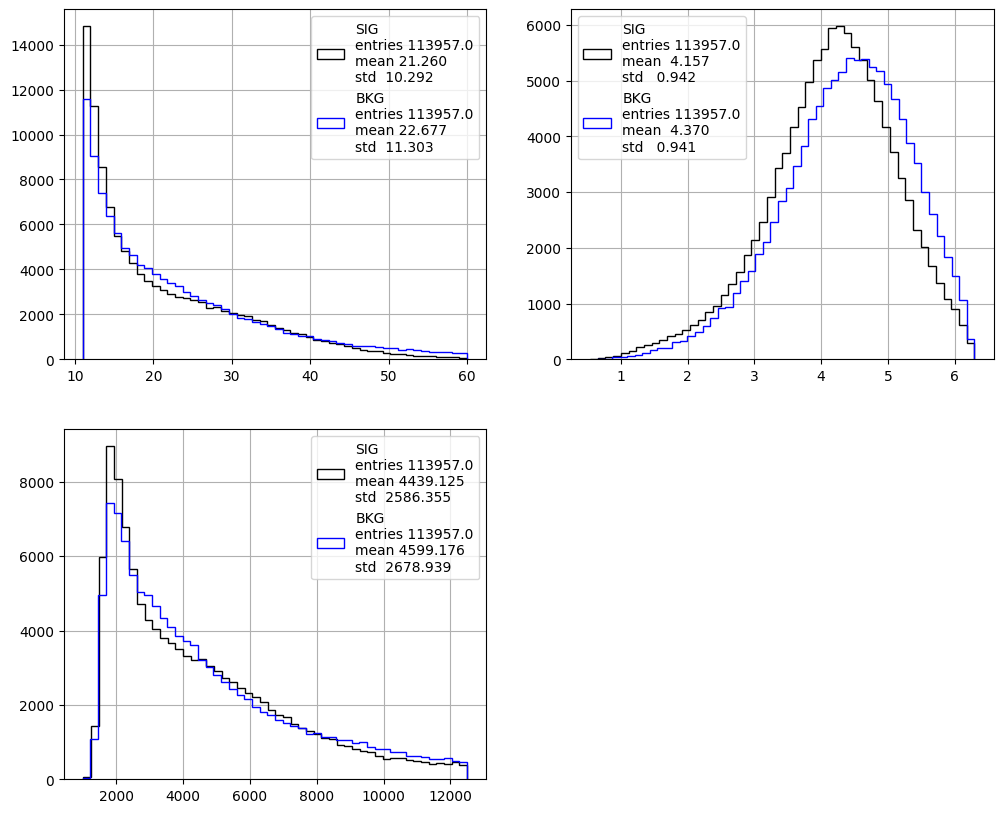

In [38]:
subplot = pltext.canvas(3)

subplot(1)
pltext.hist(real_events_1771.groupby("event_id").size(), 50, label="SIG");
pltext.hist(real_events_1766.groupby("event_id").size(), 50, label="BKG");

subplot(2)
pltext.hist(real_events_1771.groupby("event_id")["hit_pmt_calibrated_times"].std().values, 50, label="SIG");
pltext.hist(real_events_1766.groupby("event_id")["hit_pmt_calibrated_times"].std().values, 50, label="BKG");

subplot(3)
pltext.hist(real_events_1771.groupby("event_id")["hit_pmt_charges"].sum().values, 50, label="SIG");
pltext.hist(real_events_1766.groupby("event_id")["hit_pmt_charges"].sum().values, 50, label="BKG");

# Signal vs. Background Comparison And Subtraction

In [18]:
len(real_events_1771.event_id.unique()), len(real_events_1766.event_id.unique())

(3009, 3009)

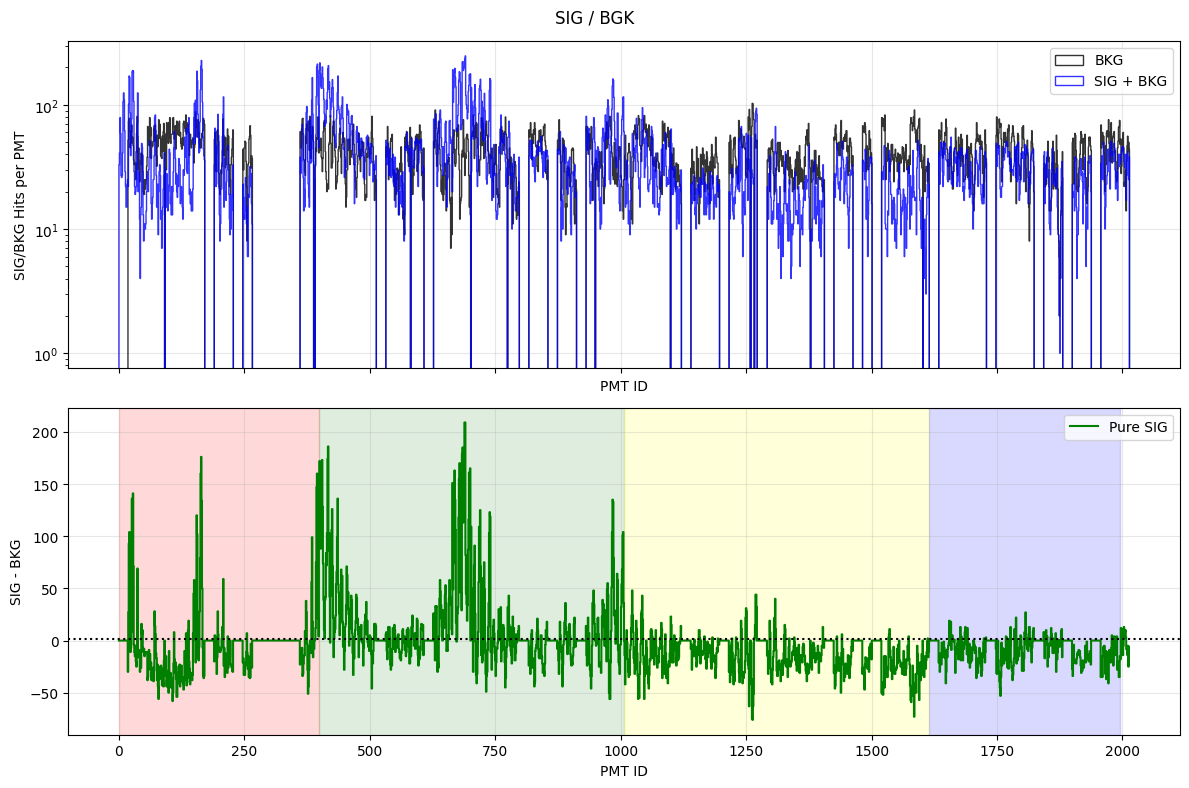

In [45]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2,2]}
)

# --- DigiHits por PMT ---
ax1.hist(real_events_1766["pmt_id"], 2014, range=(0, 2014), histtype="step", alpha=0.8, label="BKG");
ax1.hist(real_events_1771["pmt_id"], 2014, range=(0, 2014), histtype="step", alpha=0.8, label="SIG + BKG");

ax1.set_yscale("log")
ax1.set_ylabel("SIG/BKG Hits per PMT")
ax1.set_xlabel("PMT ID")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Ratio ---
bkg_hits_per_pmt = np.bincount(real_events_1766["pmt_id"], minlength=2014)
sig_hits_per_pmt = np.bincount(real_events_1771["pmt_id"], minlength=2014);

mask = bkg_hits_per_pmt > 0
pure_signal = np.zeros(2014)
pure_signal[mask] = sig_hits_per_pmt[mask] - bkg_hits_per_pmt[mask]

ax2.step(range(2014), pure_signal, where="mid", color="green", label="Pure SIG")
ax2.axhline(1.0, linestyle=":", color="k")

ax2.set_ylabel("SIG - BKG")
ax2.set_xlabel("PMT ID")
# ax2.set_yscale("log")
ax2.grid(alpha=0.3)
plt.legend();

# --- Regiones del detector ---
ax2.axvspan(0, 21*19,      color="red", alpha=0.15)
ax2.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15)
ax2.axvspan(53*19, 85*19,  color="yellow", alpha=0.15)
ax2.axvspan(85*19, 105*19, color="blue", alpha=0.15)

plt.suptitle("SIG / BGK", y=0.98)
plt.tight_layout()

# Simulation

In [7]:
npz_up         = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/npz/1Mneutrons_NiCf_piFix_QGSP_BIC_HP_pos1767_15kevents.npz'
npz_down_old   = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim_old/install/npz/1Mneutrons_NiCf_piFix_QGSP_BIC_HP_pos1771.npz'
npz_down       = '/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/npz/1Mneutrons_NiCf_piFix_QGSP_BIC_HP_pos1771_CDSON_15kevents.npz'
nevents = 15000

# Creación del DataFrame de DigiHits usando la función digihits_info_to_df
df_trueHits_up       = simple_truehits_info_to_df(npz_up).dropna()
df_trueHits_down_old = simple_truehits_info_to_df(npz_down_old).dropna()
df_trueHits_down     = simple_truehits_info_to_df(npz_down).dropna()

df_digiHits_down     = digihits_info_to_df(npz_down, nevents).dropna()

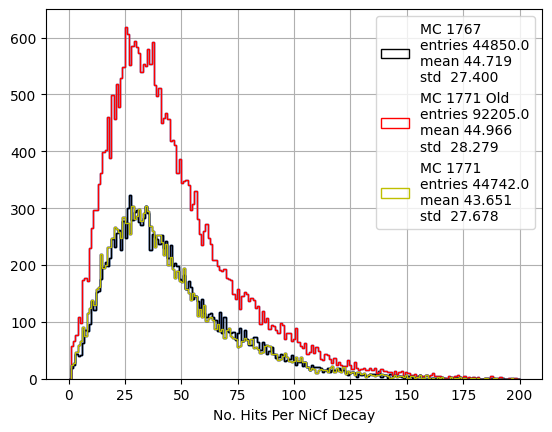

In [8]:
# Quantum Efficiency: Number Of Hits Expected In The Whole PMTs Set Per NiCf Event
# subplot = pltext.canvas(2)

# subplot(1)
pltext.hist(df_trueHits_up.groupby("event_id").count().values, 201, xylabels="No. Hits Per NiCf Decay", range=(0, 200), label="MC 1767");
pltext.hist(df_trueHits_down_old.groupby("event_id").count().values, 201, xylabels="No. Hits Per NiCf Decay", range=(0, 200), label="MC 1771 Old");
pltext.hist(df_trueHits_down.groupby("event_id").count().values, 201, xylabels="No. Hits Per NiCf Decay", range=(0, 200), label="MC 1771");

# subplot(2)
# pltext.hfit(df_trueHits_up.groupby("event_id").count().values, 21, "gaus", stats = True, residuals = True, range=(20, 40));

# Event Display

In [9]:
#1) make an instance of the event display class
eventDisplay = EventDisplay() 

#2) start by loading in the CSV file for how the mPMTs are mapped to 2d event display
#unwraps based on the mPMT slot ID 
eventDisplay.load_mPMT_positions('mPMT_2D_projection_angles.csv')

#mask out mPMT slots - newer WCSim doesn't have these mPMTs loaded  
#WCTE slot numbering
# eventDisplay.mask_mPMTs([45,77,79,27,32,85,91,99,12,14,16,18])
#WCSim container numbering
# eventDisplay.mask_mPMTs([20,73,38,49,55,65,67,33,71,92,101,95])

#3) load the WCSim mapping tube no to slot number
#for WCSim using the numpy output we need the mapping between the tube_number in WCSim and the slot and mPMT number in the detector
#this can be obtained from the geofile that WCSim produces 
#This changes if the CDS is implemented or not
eventDisplay.load_wcsim_tubeno_mapping("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim/install/geofile_NuPRISMBeamTest_16cShort_mPMT.txt")

# Create Invalid PMTs Array

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

# Cargar los datos de gaps del análisis anterior
with open('/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk/WCSim_old/install/npz/gap_analysis_data.json', 'r') as f:
    gap_data = json.load(f)
invalid_pmt_id = []
for i in range(len(gap_data["gaps_detalle"])):
    invalid_pmt_id.append(gap_data["gaps_detalle"][i]["numeros_faltantes"])

invalid_pmt_id = np.concatenate(invalid_pmt_id)

# QE Analysis

### DigiHits

In [19]:
no_candidates = real_events_1771.event_id.nunique()

mc_event_ids = df_digiHits_down.event_id.unique()[:no_candidates]

mc_equal_stats = df_digiHits_down[
    df_digiHits_down.event_id.isin(mc_event_ids)
]

In [20]:
no_candidates, len(mc_equal_stats.event_id.unique())

(3009, 3009)

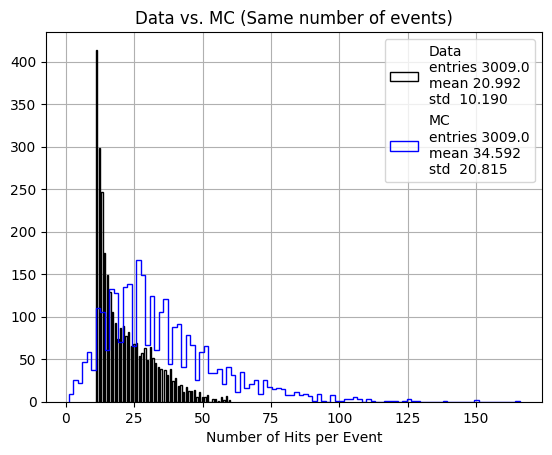

In [21]:
pltext.hist(real_events_1771.groupby("event_id").size().values, 100, label="Data");
pltext.hist(mc_equal_stats.groupby("event_id").size().values,   100, label="MC", xylabels="Number of Hits per Event");

plt.title("Data vs. MC (Same number of events)");

In [22]:
data = mc_equal_stats
tube_no = data["digi_hit_pmt"] + 1
mPMT_id_1771, PMT_pos_1771 = eventDisplay.map_wcsim_tubeno_to_slot_pmt_id(tube_no)
mc_pmt_id = mPMT_id_1771 * 19 + PMT_pos_1771

mc_pmt_id = np.array(
    [pmt for pmt in mc_pmt_id if pmt not in invalid_pmt_id]
)

[89  8  8 ... 59 68 41]


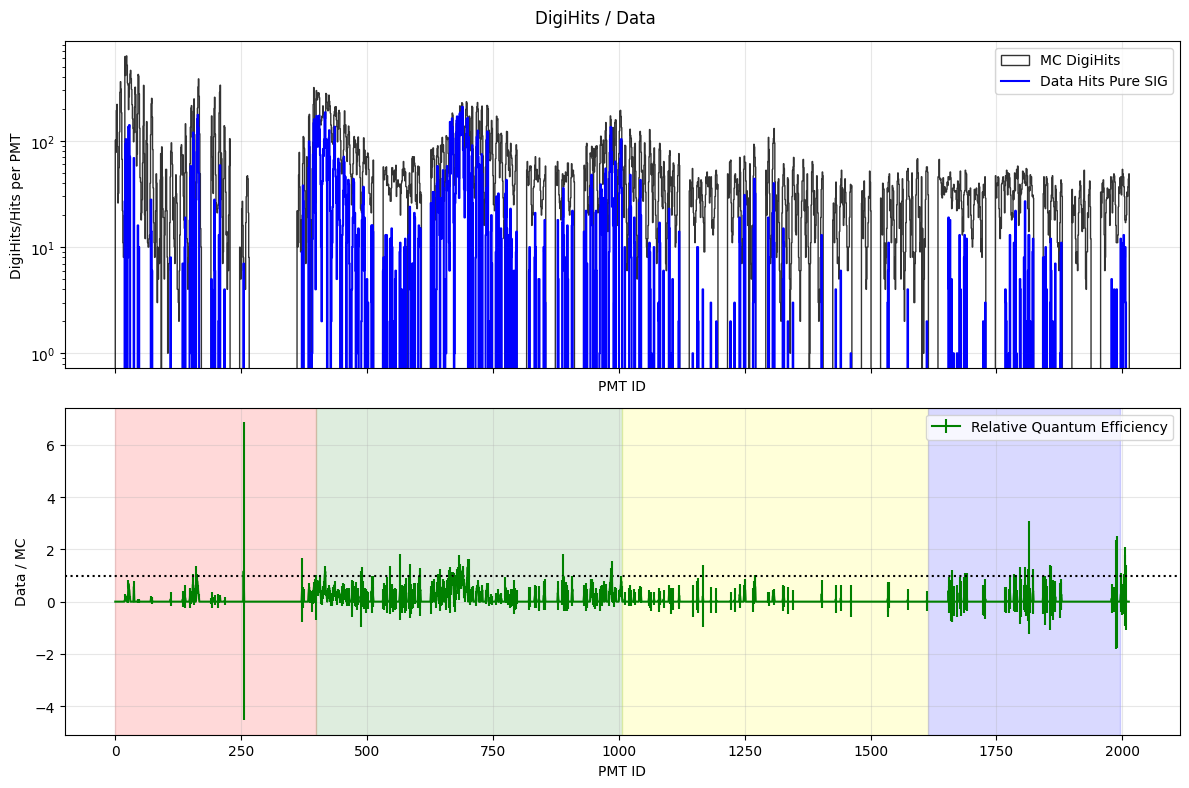

In [47]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2,2]}
)

# --- DigiHits por PMT ---
ax1.hist(mc_pmt_id,                  2014, range=(0, 2014), histtype="step", alpha=0.8, label="MC DigiHits");
# ax1.hist(real_events_1771["pmt_id"], 2014, range=(0, 2014), histtype="step", alpha=0.8, label="Data Hits");
ax1.step(range(2014), pure_signal, where="mid", color="blue", label="Data Hits Pure SIG")

ax1.set_yscale("log")
ax1.set_ylabel("DigiHits/Hits per PMT")
ax1.set_xlabel("PMT ID")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Ratio ---
mc_hits_per_pmt = np.bincount(mc_pmt_id, minlength=2014)
# data_hits_per_pmt = np.bincount(real_events_1771["pmt_id"], minlength=2014);
data_hits_per_pmt = pure_signal;

mask = (mc_hits_per_pmt > 0) & (data_hits_per_pmt > 0)
relative_qe = np.zeros(2014)
relative_qe[mask] = np.divide(data_hits_per_pmt[mask], mc_hits_per_pmt[mask])
error_data = np.sqrt(len(data_hits_per_pmt[mask]))
error_mc   = np.sqrt(len(mc_hits_per_pmt[mask]))
error_relative_qe = np.sqrt((1/mc_hits_per_pmt[mask])**2*(error_data)**2 + (data_hits_per_pmt[mask]/(mc_hits_per_pmt[mask])**2)**2*(error_mc)**2)
error_relative_qe_full = np.zeros(2014)
error_relative_qe_full[mask] = error_relative_qe

ax2.errorbar(range(2014), relative_qe, yerr=error_relative_qe_full, color="green", markersize=3, label="Relative Quantum Efficiency")
# ax2.scatter(range(2014), relative_qe, color="green", s=3, label="Relative Quantum Efficiency")
ax2.axhline(1.0, linestyle=":", color="k")

ax2.set_ylabel("Data / MC")
ax2.set_xlabel("PMT ID")
ax2.grid(alpha=0.3)
# ax2.set_ylim(-2, 4)
plt.legend()

# --- Regiones del detector ---
ax2.axvspan(0, 21*19,      color="red", alpha=0.15)
ax2.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15)
ax2.axvspan(53*19, 85*19,  color="yellow", alpha=0.15)
ax2.axvspan(85*19, 105*19, color="blue", alpha=0.15)

plt.suptitle("DigiHits / Data", y=0.98)
plt.tight_layout()

In [12]:
mean_qe = np.nanmean(relative_qe)
mse = np.nanmean((relative_qe - mean_qe)**2)

mean_qe, mse

(np.float64(1.0861326818040846), np.float64(1.888685809481609))

### TrueHits

In [13]:
no_candidates = real_events_1771.event_id.nunique()

mc_event_ids = df_trueHits_down.event_id.unique()[:no_candidates]

mc_equal_stats = df_trueHits_down[
    df_trueHits_down.event_id.isin(mc_event_ids)
]

In [14]:
no_candidates, len(mc_equal_stats.event_id.unique())

(2401, 2401)

In [15]:
data = mc_equal_stats
tube_no = data["true_hit_pmt"] + 1
mPMT_id_1771, PMT_pos_1771 = eventDisplay.map_wcsim_tubeno_to_slot_pmt_id(tube_no)
mc_pmt_id = mPMT_id_1771 * 19 + PMT_pos_1771

mc_pmt_id = np.array(
    [pmt for pmt in mc_pmt_id if pmt not in invalid_pmt_id]
)

[89  8  8 ... 12 41 42]


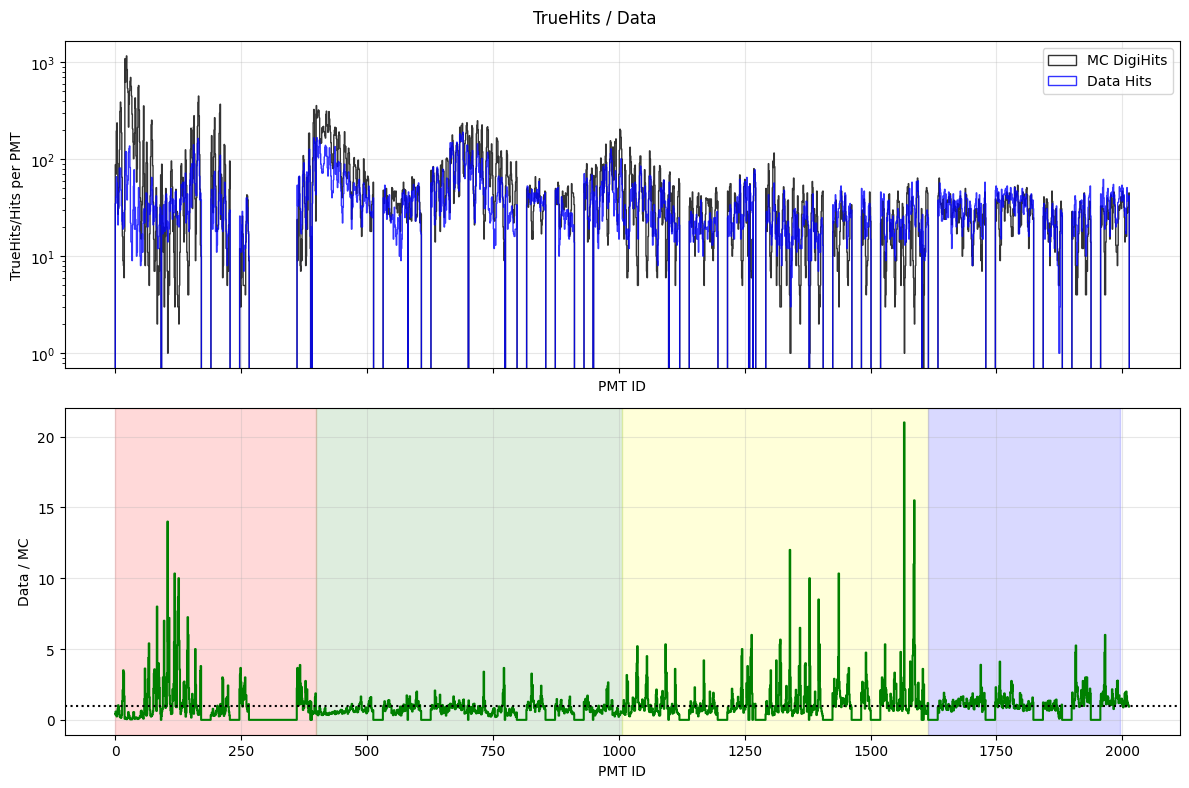

In [35]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 2]}
)

# --- DigiHits por PMT ---
ax1.hist(mc_pmt_id,                  2014, range=(0, 2014), histtype="step", alpha=0.8, label="MC DigiHits");
ax1.hist(real_events_1771["pmt_id"], 2014, range=(0, 2014), histtype="step", alpha=0.8, label="Data Hits");

ax1.set_yscale("log")
ax1.set_ylabel("TrueHits/Hits per PMT")
ax1.set_xlabel("PMT ID")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Ratio ---
mc_hits_per_pmt   = np.bincount(mc_pmt_id, minlength=2014)
data_hits_per_pmt = np.bincount(real_events_1771["pmt_id"], minlength=2014);

mask = mc_hits_per_pmt > 0
relative_qe = np.zeros(2014)
relative_qe[mask] = data_hits_per_pmt[mask] / mc_hits_per_pmt[mask]

ax2.step(range(2014), relative_qe, where="mid", color="green")
ax2.axhline(1.0, linestyle=":", color="k")

ax2.set_ylabel("Data / MC")
ax2.set_xlabel("PMT ID")
ax2.grid(alpha=0.3)

# --- Regiones del detector ---
ax2.axvspan(0, 21*19,      color="red", alpha=0.15)
ax2.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15)
ax2.axvspan(53*19, 85*19,  color="yellow", alpha=0.15)
ax2.axvspan(85*19, 105*19, color="blue", alpha=0.15)

plt.suptitle("TrueHits / Data", y=0.98)
plt.tight_layout()

In [17]:
mean_qe = np.nanmean(relative_qe)
mse = np.nanmean((relative_qe - mean_qe)**2)

mean_qe, mse

(np.float64(0.9848652841297489), np.float64(1.741578683010025))

# Gain Calibration Comparison

In [18]:
for i in [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]:
    df = pd.DataFrame(np.load(f"/mnt/lustre/scratch/nlsas/home/usc/ie/dcr/hk/nicf_data/data/gain_calibration_elena_v2/results/High_statistics_run2307_chunk{i}.npz")["results"])
    if i == 0:
        df_result = df
    else:
        df_result = pd.concat([df_result, df], ignore_index=True)

df_result["pmt_id"] = df_result["slot_id"]*19 + df_result["pos_id"]
df_elena = df_result[["pmt_id", "gain"]]
df_merge = pd.merge(real_events_1771, df_elena, how="inner", on=["pmt_id"])
df_merge["calibrated_charge_PEs"] = df_merge["hit_pmt_charges"].values/df_merge["gain"].values

In [19]:
no_candidates = df_merge.event_id.nunique()

mc_event_ids = df_trueHits_down.event_id.unique()[:no_candidates]

mc_equal_stats = df_trueHits_down[
    df_trueHits_down.event_id.isin(mc_event_ids)
]

print(no_candidates, len(mc_equal_stats.event_id.unique()))

data = mc_equal_stats
tube_no = data["true_hit_pmt"] + 1
mPMT_id_1771, PMT_pos_1771 = eventDisplay.map_wcsim_tubeno_to_slot_pmt_id(tube_no)
mc_pmt_id = mPMT_id_1771 * 19 + PMT_pos_1771

mc_pmt_id = np.array(
    [pmt for pmt in mc_pmt_id if pmt not in invalid_pmt_id]
)

pe_data = (
    df_merge
    .groupby("pmt_id")["calibrated_charge_PEs"]
    .sum()
)

# Aseguramos vector completo de 2014 PMTs
data_pe = np.zeros(2014)
data_pe[pe_data.index.values] = pe_data.values

2401 2401
[89  8  8 ... 12 41 42]


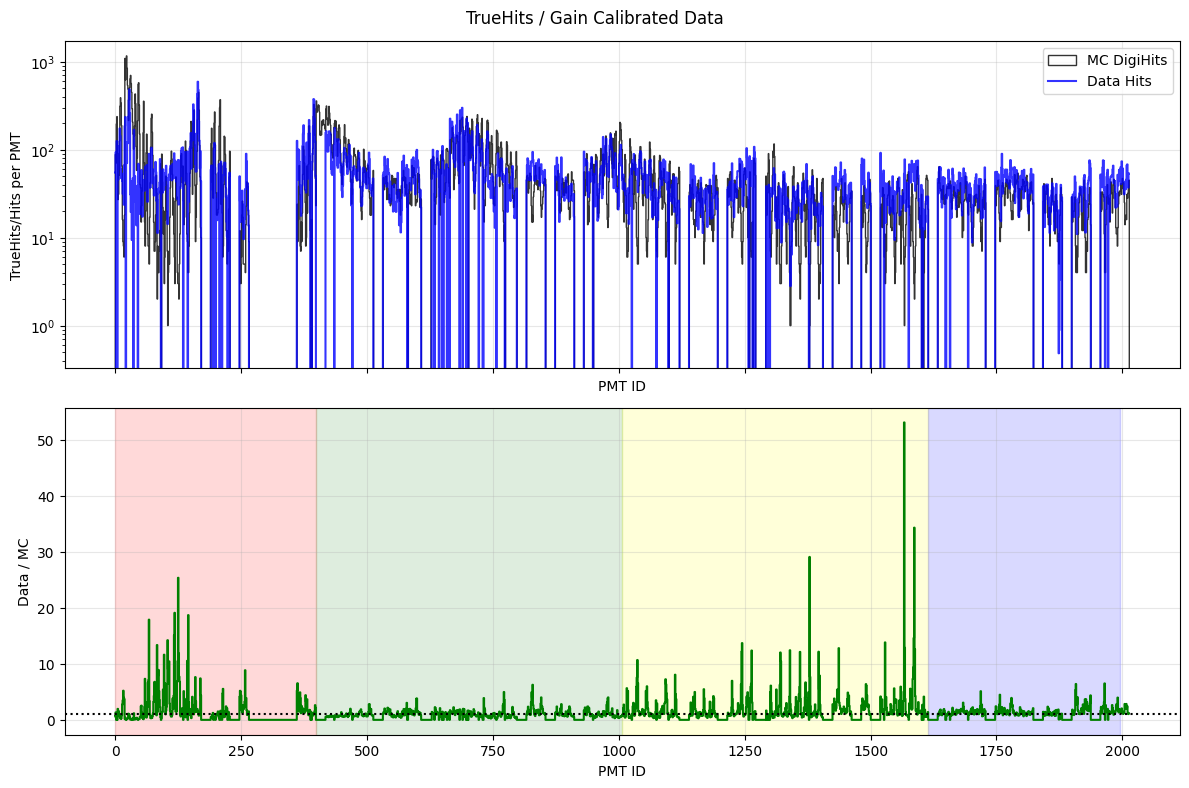

In [34]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 2]}
)

# --- DigiHits por PMT ---
ax1.hist(mc_pmt_id,                  2014, range=(0, 2014), histtype="step", alpha=0.8, label="MC DigiHits");
ax1.step(range(2014), data_pe, where="mid", label="Data Hits", alpha=0.8)

ax1.set_yscale("log")
ax1.set_ylabel("TrueHits/Hits per PMT")
ax1.set_xlabel("PMT ID")
ax1.legend()
ax1.grid(alpha=0.3)

# --- Ratio ---
mc_hits_per_pmt = np.bincount(mc_pmt_id, minlength=2014)
pes_per_pmt = data_pe

mask = mc_hits_per_pmt > 0
relative_qe = np.zeros(2014)
relative_qe[mask] = pes_per_pmt[mask] / mc_hits_per_pmt[mask]

ax2.step(range(2014), relative_qe, where="mid", color="green")
ax2.axhline(1.0, linestyle=":", color="k")

ax2.set_ylabel("Data / MC")
ax2.set_xlabel("PMT ID")
ax2.grid(alpha=0.3)

# --- Regiones del detector ---
ax2.axvspan(0, 21*19,      color="red", alpha=0.15)
ax2.axvspan(21*19, 53*19,  color="forestgreen", alpha=0.15)
ax2.axvspan(53*19, 85*19,  color="yellow", alpha=0.15)
ax2.axvspan(85*19, 105*19, color="blue", alpha=0.15)

plt.suptitle("TrueHits / Gain Calibrated Data", y=0.98)
plt.tight_layout()

In [30]:
mean_qe = np.nanmean(relative_qe)
mse = np.nanmean((relative_qe - mean_qe)**2)

mean_qe, mse

(np.float64(1.4264473864217377), np.float64(6.256440648923439))